In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
def ResponseMatrix(sample,acceptance,fullsel,vart,varr,bin_edges,wlab,univ=-1,wvar=''):
        #get number of signal events at true level before selection
        truevals = sample.query(acceptance,engine="python")[vart]
        tweights = sample.query(acceptance,engine="python")[wlab]
        # print("tweights sum: ", np.sum(tweights))
        if univ>=0:
            vweights = sample.query(acceptance,engine="python")[wvar]
            if (np.stack(vweights).ndim>1):
                #multisim, pick specific universe
                vweights = np.stack(vweights)[:,univ]/1000.
            vweights[np.isnan(vweights)] = 1
            vweights[vweights > 100] = 1
            vweights[vweights < 0] = 1
            vweights[vweights == np.inf] = 1
            tweights = tweights*vweights
            # print("vweights sum: ", np.sum(vweights))
            # print("tweights sum fixed: ", np.sum(tweights))
        n, bins = np.histogram(truevals,weights=tweights,bins=bin_edges)
        # print("Resp denominator: \n", n)
        #get number of signal events at reco and true level after selection
        x = sample.query(acceptance+' and '+fullsel,engine="python")[vart]
        y = sample.query(acceptance+' and '+fullsel,engine="python")[varr]
        w = sample.query(acceptance+' and '+fullsel,engine="python")[wlab]
        if univ>=0:
            vw = sample.query(acceptance+' and '+fullsel,engine="python")[wvar]
            if (np.stack(vw).ndim>1):
                #multisim, pick specific universe
                vw = np.stack(vw)[:,univ]/1000.
            vw[np.isnan(vw)] = 1
            vw[vw > 100] = 1
            vw[vw < 0] = 1
            vw[vw == np.inf] = 1
            w = w*vw
        H, xb, yb = np.histogram2d(x,y,weights=w,bins=[bin_edges,bin_edges])
        # print("Resp numerator: \n", np.transpose(H))
        #get response matrix
        rm = np.transpose(H)/n
        return rm, xb, yb

def sys_err_unisim_with_resp_func(rundata, signame, var_name, true_var_name, query, acceptance, n_bins=None, x_range=None, bin_edges=None):
    #this is not done for lee

    # Sometimes n_bins is none in the Binning object if using variable bin sizes
    if bin_edges is not None:
        n_bins = len(bin_edges) - 1
        bins = bin_edges
    elif x_range is None:
        bins = n_bins
    else:
        bins = np.linspace(x_range[0],x_range[1],n_bins+1)

    weightVarCV = "weights"
    weightVarVar = "weights_no_tune"

    knob_v = ['knobRPA','knobCCMEC','knobAxFFCCQE','knobVecFFCCQE','knobDecayAngMEC','knobThetaDelta2Npi']
    knob_n = [2,1,1,1,1,1]

    n_tot_v = []
    for u,knob in enumerate(knob_v):
        n_tot_v.append( np.empty([ knob_n[u] ,n_bins]) )
        n_tot_v[-1].fill(0)

    n_cv_tot = np.empty(n_bins)
    n_cv_tot.fill(0)

    for t, df in rundata.items():
        # print(t)
        if t in ["ext", "data"]:
            continue

        tree = rundata[t]

        extra_query = ""
        # if t == "mc":
        #     extra_query = "& " + self.nu_pdg
        if t == signame:
            extra_query = "& ~(" + acceptance +")"

        queried_tree = tree.query(query+extra_query,engine="python")
        variable = queried_tree[var_name]
        spline_fix_cv  = queried_tree[weightVarCV]
        spline_fix_var = queried_tree[weightVarVar]

        n_cv, bins = np.histogram(variable,bins=bins,weights=spline_fix_cv)
        n_cv_tot += n_cv

        for n,knob in enumerate(knob_v):
            # print(knob)
            weight_up = queried_tree['%sup'%knob].values
            weight_up[np.isnan(weight_up)] = 1
            weight_up[weight_up > 100] = 1
            weight_up[weight_up < 0] = 1
            weight_up[weight_up == np.inf] = 1
            n_up, bins = np.histogram(variable, weights=weight_up * spline_fix_var,bins=bins)
            n_tot_v[n][0] += n_up

            if (knob_n[n] == 2):
                weight_dn = queried_tree['%sdn'%knob].values
                weight_dn[np.isnan(weight_dn)] = 1
                weight_dn[weight_dn > 100] = 1
                weight_dn[weight_dn < 0] = 1
                weight_dn[weight_dn == np.inf] = 1
                n_dn, bins = np.histogram(variable, weights=weight_dn * spline_fix_var,bins=bins)
                n_tot_v[n][1] += n_dn

    # bkg_vars_dict = dict()
    # for n, knob in enumerate(knob_v):
    #      bkg_vars_dict[knob] = n_tot_v[n]
    # print("My bkg var dict: \n", bkg_vars_dict)
    # print()

    # do stuff for signal sample
    tree = rundata[signame]

    extra_query = ""
    # if signame == "mc":
    #     extra_query += "& " + self.nu_pdg

    queried_tree = tree.query(query+"& (" + acceptance +")"+extra_query,engine="python")
    variable = queried_tree[var_name]
    #print ('N universes is :',len(syst_weights))
    spline_fix_cv  = queried_tree[weightVarCV]

    n_cv, bins = np.histogram(variable,bins=bins,weights=spline_fix_cv)
    n_cv_tot += n_cv
    # print("CV hist: ", n_cv_tot)
    true_variable = tree.query(acceptance,engine="python")[true_var_name]
    spline_fix_cv  = tree.query(acceptance,engine="python")[weightVarCV]
    t_cv, bins = np.histogram(true_variable,bins=bins,weights=spline_fix_cv)
    # print("t_cv: ", t_cv)
    for n,knob in enumerate(knob_v):
            # print(knob, ":")
            # print()
            rmv_up, xb, yb = ResponseMatrix(tree,acceptance,query,true_var_name,var_name,\
                                                    bins,weightVarVar,0,'%sup'%knob)
            rp_up = rmv_up.dot(t_cv)
            n_tot_v[n][0] += rp_up
            # print("resp up: \n", rmv_up)
            # print()
            # print("rp up: \n", rp_up)
            # print()
            if (knob_n[n] == 2):
                rmv_dn, xb, yb = ResponseMatrix(tree,acceptance,query,true_var_name,var_name,\
                                                        bins,weightVarVar,0,'%sdn'%knob)
                rp_dn = rmv_dn.dot(t_cv)
                n_tot_v[n][1] += rp_dn
                # print("resp dn: \n", rmv_dn)
                # print()
                # print("rp dn: \n", rp_dn)
                # print()

    cov = np.empty([len(n_cv), len(n_cv)])
    cov.fill(0)

    for n,knob in enumerate(knob_v):

        this_cov = np.empty([len(n_cv), len(n_cv)])
        this_cov.fill(0)

        #print ('knob : %s has :'%knob)
        #print ('n_cv : ',n_cv_tot)
        #print ('n_up : ',n_tot_v[n][0])
        #print ('n_dn : ',n_tot_v[n][1])

        if (knob_n[n] == 2):
            for i in range(len(n_cv)):
                #print ('knob %s has CV: %.0f, VAR UP: %.0f, VAR DN: %.0f entries'%(knob,n_cv_tot[i],n_tot_v[n][0][i],n_tot_v[n][1][i]))
                for j in range(len(n_cv)):
                    this_cov[i][j] += (n_tot_v[n][0][i] - n_cv_tot[i]) * (n_tot_v[n][0][j] - n_cv_tot[j])
                    this_cov[i][j] += (n_tot_v[n][1][i] - n_cv_tot[i]) * (n_tot_v[n][1][j] - n_cv_tot[j])
            this_cov /= 2.

        if (knob_n[n] == 1):
            for i in range(len(n_cv)):
                #print ('knob %s has CV: %.0f, VAR: %.0f entries'%(knob,n_cv_tot[i],n_tot_v[n][0][i]))
                for j in range(len(n_cv)):
                    this_cov[i][j] += (n_tot_v[n][0][i] - n_cv_tot[i]) * (n_tot_v[n][0][j] - n_cv_tot[j])

        cov += this_cov

    return cov

def sys_err_with_resp_func(rundata, signame, var_name, true_var_name, query, acceptance, n_bins=None, x_range=None, bin_edges=None, wname="weightsGenie"):
        #this is not done for lee

       # Sometimes n_bins is none in the Binning object if using variable bin sizes
        if bin_edges is not None:
            n_bins = len(bin_edges) - 1
            bins = bin_edges
        elif x_range is None:
            bins = n_bins
        else:
            bins = np.linspace(x_range[0],x_range[1],n_bins+1)

        weightVarCV = "weights"
        weightVarVar = "weights_no_tune"

        # how many universes?
        Nuniverse = 100 #len(df)

        n_tot = np.empty([Nuniverse, n_bins])
        n_cv_tot = np.empty(n_bins)
        n_tot.fill(0)
        n_cv_tot.fill(0)

        for t, df in rundata.items():
            if t in ["ext", "data"]:
                continue

            tree = rundata[t]

            extra_query = ""
            # if t == "mc":
            #     extra_query = "& " + self.nu_pdg # "& ~(abs(nu_pdg) == 12 & ccnc == 0) & ~(npi0 == 1 & category != 5)"
            if t == signame:
                extra_query = "& ~(" + acceptance +")"

            queried_tree = tree.query(query+extra_query,engine="python")
            variable = queried_tree[var_name]
            syst_weights = queried_tree[wname]
            #print ('N universes is :',len(syst_weights))
            spline_fix_cv  = queried_tree[weightVarCV]
            spline_fix_var = queried_tree[weightVarVar]

            s = syst_weights

            df = pd.DataFrame(s.values.tolist())
            #print (df)
            #print(t,wname,np.shape(df))
            #continue

            n_cv, bins = np.histogram(
                variable,
                bins=bins,
                weights=spline_fix_cv)
            n_cv_tot += n_cv

            if not df.empty:
                for i in range(Nuniverse):
                    weight = df[i].values / 1000.
                    weight[np.isnan(weight)] = 1
                    weight[weight > 100] = 1
                    weight[weight < 0] = 1
                    weight[weight == np.inf] = 1

                    n, bins = np.histogram(
                        variable, weights=weight*spline_fix_var,bins=bins)
                    n_tot[i] += n

        # do stuff for signal sample
        tree = rundata[signame]

        extra_query = ""
        # if signame == "mc":
        #     extra_query += "& " + self.nu_pdg

        queried_tree = tree.query(query+"& (" + acceptance +")"+extra_query,engine="python")
        variable = queried_tree[var_name]
        syst_weights = queried_tree[wname]
        #print ('N universes is :',len(syst_weights))
        spline_fix_cv  = queried_tree[weightVarCV]

        s = syst_weights

        df = pd.DataFrame(s.values.tolist())
        #print (df)
        #print(t,wname,np.shape(df))
        #continue

        #print(bins)
        #print(variable)
        #print(spline_fix_cv)
        n_cv, bins = np.histogram(
            variable,
            bins=bins,
            weights=spline_fix_cv)
        n_cv_tot += n_cv
        #print('n_cv',n_cv)

        true_variable = tree.query(acceptance,engine="python")[true_var_name]
        spline_fix_cv  = tree.query(acceptance,engine="python")[weightVarCV]
        t_cv, bins = np.histogram(
            true_variable,
            bins=bins,
            weights=spline_fix_cv)
        #print('t_cv',t_cv)

        if not df.empty:
            for i in range(Nuniverse):
                rmv, xb, yb = ResponseMatrix(tree,acceptance,query,true_var_name,var_name,\
                                                  bins,weightVarVar,i,wname)
                #print(rmv)
                rp = rmv.dot(t_cv)
                #print("variation: ",rp)
                n_tot[i] += rp

        # now compute the covariance
        cov = np.empty([len(n_cv), len(n_cv)])
        cov.fill(0)

        for n in n_tot:
            for i in range(len(n_cv)):
                for j in range(len(n_cv)):
                    cov[i][j] += (n[i] - n_cv_tot[i]) * (n[j] - n_cv_tot[j])

        cov /= Nuniverse

        return cov

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

from microfit import detsys
from microfit.xsec_signal_generator import XsecCovarHistGenerator

from microfit import xsec_covariances as xs

In [4]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons",
    "TrueNElec", "TrueNProt", "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial",
    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len", "reco_e",
    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid", "RecoElectron_conversion_dist",
    "pi0_radlen1", "pi0_radlen2", "pi0_score", "nonpi0_score", "bkg_score",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",
    "ccnc",
]

In [5]:
# from typing import Optional, Tuple, Union
# from microfit.histogram import HistogramGenerator
# from microfit.histogram import Histogram, MultiChannelHistogram
# from microfit.statistics import covariance

# class XsecCovarHistGenerator(HistogramGenerator):

#     def __init__(self, *args, true_var_name=None, signal_query=None, uncut_signal_df=None, **kwargs):
#         self.true_var_name = true_var_name
#         assert signal_query is not None
#         self.signal_query = signal_query
#         assert uncut_signal_df is not None
#         self.uncut_signal_df = uncut_signal_df
#         super().__init__(*args, **kwargs)

#     def calculate_unisim_uncertainties(
#         self,
#         central_value_hist: Optional[Histogram] = None,
#         extra_query: Optional[str] = None,
#         return_histograms: bool = False,
#         skip_covariance: bool = False,
#     ):
#         # First, apply the usual calculation to the background only
#         background_query = f"~({self.signal_query})"
#         background_hist_dict = None
#         background_covariance = None
#         background_extra_query = background_query if extra_query is None else background_query + " & " + extra_query
#         background_covariance, background_vars_dict = super().calculate_unisim_uncertainties(
#             central_value_hist = central_value_hist,
#             extra_query = background_extra_query,
#             return_histograms = True,
#         )

#         # print("bkg var dict: \n", background_vars_dict)
#         # print()
#          # Calculate the signal variation hists
        
#         knob_v = ['knobRPA','knobCCMEC','knobAxFFCCQE','knobVecFFCCQE','knobDecayAngMEC','knobThetaDelta2Npi']
#         knob_n = [2,1,1,1,1,1]
#         n_tot_v = [] # this will store the variation hists
#         for u, knob in enumerate(knob_v):
#             n_tot_v.append(np.zeros([ knob_n[u] , self.binning.n_bins]))

#         if self.true_var_name is None:
#             label = self.binning.variable.lstrip("Reco")
#             self.true_var_name = "True" + label
        
#         if extra_query is not None:
#             sel_df = self.dataframe.query(extra_query, engine="python")
#         else:
#             sel_df = self.dataframe

#         raw_df = self.uncut_signal_df
#         queried_df = sel_df.query(f"{self.signal_query}", engine="python")
#         base_weight_column = "weights_no_tune"

#         # Calculate the true signal CV that stays constant in all the universes
#         true_sig = raw_df.query(self.signal_query, engine="python")
#         true_variable = true_sig[self.true_var_name]
#         true_var_weightsCV  = true_sig["weights"]
#         t_cv, bins = np.histogram(true_variable, bins=self.binning.bin_edges, weights=true_var_weightsCV)
#         # print("t_cv: ", t_cv)
#         sig_vars_dict = dict()
#         for n,knob in enumerate(knob_v):
#             # print(knob, ":")
#             # print()
#             rmv_up, xb, yb = self.ResponseMatrix(raw_df, sel_df, self.signal_query, self.true_var_name, self.binning.variable, self.binning.bin_edges, base_weight_column, 0, f"{knob}up")
#             rp_up = rmv_up.dot(t_cv)
#             n_tot_v[n][0] += rp_up
#             # print("resp up: \n", rmv_up)
#             # print()
#             # print("rp up: \n", rp_up)
#             # print()
#             if (knob_n[n] == 2):
#                 rmv_dn, xb, yb = self.ResponseMatrix(raw_df, sel_df, self.signal_query, self.true_var_name, self.binning.variable, self.binning.bin_edges, base_weight_column, 0, f"{knob}dn")
#                 rp_dn = rmv_dn.dot(t_cv)
#                 n_tot_v[n][1] += rp_dn
#                 # print("resp dn: \n", rmv_dn)
#                 # print()
#                 # print("rp dn: \n", rp_dn)
#                 # print()
#             sig_vars_dict[knob] = n_tot_v[n]
        
#         # print("sig var dict: \n", sig_vars_dict)
#         # print()

#         # Add the signal and background variation hists and calculate cov matrix for each knob
#         if central_value_hist is None:
#             central_value_hist = self._histogram_multi_channel(sel_df)
#         # print("CV hist: ", central_value_hist.bin_counts)
#         # print()
#         total_cov = np.zeros((self.binning.n_bins, self.binning.n_bins))
#         total_vars_dict = dict()
#         for n,knob in enumerate(knob_v):
#             total_vars_dict[knob] = sig_vars_dict[knob] + background_vars_dict[knob]
#             # If we get to this point without having either calculated a central value hist
#             # or taken one from the cache, something is wrong
#             assert central_value_hist is not None
#             if skip_covariance:
#                 continue
#             # calculate the covariance matrix from the histograms
#             cov = covariance(
#                 total_vars_dict[knob],
#                 central_value_hist.bin_counts,
#                 allow_approximation=True,
#                 debug_name=knob,
#                 tolerance=1e-8,
#             )
#             self.logger.debug(
#                 f"Bin-wise error contribution for knob {knob}: {np.sqrt(np.diag(cov))}"
#             )
#             # add it to the total covariance matrix
#             total_cov += cov
#         # print("total var dict: \n", total_vars_dict)
#         # print()
#         if return_histograms:
#             return total_cov, total_vars_dict
#         return total_cov


#     def calculate_multisim_uncertainties(
#         self,
#         multisim_weight_column: str,
#         weight_rescale: float = 1 / 1000,
#         weight_column: Optional[str] = None,
#         central_value_hist: Optional[Union[Histogram, MultiChannelHistogram]] = None,
#         extra_query: Optional[str] = None,
#         return_histograms: bool = False,
#     ) -> Union[np.ndarray, Tuple[np.ndarray, Optional[np.ndarray]]]:
#         if multisim_weight_column in ["weightsFlux", "weightsReint"]:
#             return super().calculate_multisim_uncertainties(
#                 multisim_weight_column = multisim_weight_column,
#                 weight_rescale = weight_rescale,
#                 weight_column = weight_column,
#                 central_value_hist = central_value_hist,
#                 extra_query = extra_query,
#                 return_histograms = return_histograms, # type: ignore
#             )
#         assert multisim_weight_column == "weightsGenie"
#         if weight_column is None:
#             weight_column = (
#                 "weights_no_tune" if multisim_weight_column == "weightsGenie" else "weights"
#             )

#         # First, apply the usual calculation to the background only
#         background_query = f"~({self.signal_query})"
#         background_histograms = None
#         background_covariance = None
#         background_extra_query = background_query if extra_query is None else background_query + " & " + extra_query
#         background_covariance, background_histograms = super().calculate_multisim_uncertainties(
#             multisim_weight_column=multisim_weight_column,
#             weight_rescale=weight_rescale,
#             weight_column=weight_column,
#             central_value_hist=central_value_hist,
#             extra_query=background_extra_query,
#             return_histograms=True
#         )

#          # Calculate the signal variation hists

#         if self.true_var_name is None:
#             label = self.binning.variable.lstrip("Reco")
#             self.true_var_name = "True" + label
        
#         if extra_query is not None:
#             sel_df = self.dataframe.query(extra_query, engine="python")
#         else:
#             sel_df = self.dataframe
    
#         # universe_histograms = self._multi_channel_universes(
#         #     dataframe,
#         #     weight_column,
#         #     multisim_weight_column,
#         #     weight_rescale=weight_rescale,
#         # )

#         raw_df = self.uncut_signal_df
#         Nuniverse = 100 #len(raw_df[multisim_weight_column][0]) # should be 100 in the 2024 PELEE n-tuples
#         n_tot = np.zeros([Nuniverse, self.binning.n_bins]) # this will store the variation hists (rows)
#         queried_df = sel_df.query(f"{self.signal_query}", engine="python")
#         syst_weights = queried_df[multisim_weight_column]

#         # Calculate the signal variation hists and store them

#         weights_df = pd.DataFrame(syst_weights.values.tolist()) # df of multisim weights that have been flattened horizontally - i.e. Nuniv (100) columns per row

#         # Calculate the true signal CV that stays constant in all the universes
#         true_sig = raw_df.query(self.signal_query, engine="python")
#         true_variable = true_sig[self.true_var_name]
#         true_var_weightsCV  = true_sig["weights"]
#         t_cv, bins = np.histogram(true_variable, bins=self.binning.bin_edges, weights=true_var_weightsCV)

#         if not weights_df.empty:
#             for i in range(Nuniverse):
#                 rmv, xb, yb = self.ResponseMatrix(raw_df, sel_df, self.signal_query, self.true_var_name, self.binning.variable, self.binning.bin_edges, weight_column, i, multisim_weight_column)
#                 #print(rmv)
#                 rp = rmv.dot(t_cv)
#                 #print("variation: ",rp)
#                 n_tot[i] += rp

#         # Add the signal and background variation hists
#         universe_hists = background_histograms + n_tot

#         # Now finally compute the covariance
#         if central_value_hist is None:
#             central_value_hist = self._histogram_multi_channel(sel_df)
#         # calculate the covariance matrix from the histograms
#         final_covariance = covariance(
#             universe_hists,
#             central_value_hist.bin_counts,
#             allow_approximation=True,
#             tolerance=1e-8,
#         )

#         if return_histograms:
#              return final_covariance, universe_hists
#         else:
#              return final_covariance
        
#     def ResponseMatrix(self, raw_df, sel_df, truth_def, true_var_name, var_name, bin_edges, base_weight_Var, univ=-1, wname=""):

#         """Calculate the response matrix.

#             Parameters
#             ----------
#             raw_df : pandas dataframe
#                 The dataframe containing the signal events with no selection (truth and/or reco) applie to it.
#             sel_df : pandas dataframe
#                 The dataframe with the full selection applied.
#             truth_def : str
#                 A set of cuts specifying the signal definition using truth-level variables.
#             var_name : str
#                 The name of the reconstructed variable you are calculating the covariance for.
#             true_var_name : str
#                 The name of the truth-level variable corresponding to var_name. 
#             bin_edges : np.ndarray
#                 Array of bin edges.
#             base_weight_Var : str
#                 Name of the column containing the baseline weights of the events. 
#             univ : int
#                 The universe index.
#             wname : str
#                 Name of multisim weight column. 

#             Returns
#             -------
#             rm : array_like
#                 Response matrix of the bin counts.
#             xb : array_like
#                 Horizontal bin edges.
#             yb : array_like
#                 Vertical bin edges. 
#         """ # type: ignore
    
#         # Get number of signal events at true level before selection
#         true_sig = raw_df.query(truth_def, engine="python")
#         truevals = true_sig[true_var_name]
#         tweights = true_sig[base_weight_Var]
#         # print("tweights sum: ", np.sum(tweights))
#         if univ>=0:
#             vweights = true_sig[wname]
#             if (np.stack(vweights).ndim>1):
#                 #multisim, pick specific universe
#                 vweights = np.stack(vweights)[:,univ]/1000.
#             vweights[np.isnan(vweights)] = 1
#             vweights[vweights > 100] = 1
#             vweights[vweights < 0] = 1
#             vweights[vweights == np.inf] = 1
#             tweights = tweights * vweights
#             # print("vweights sum: ", np.sum(vweights))
#             # print("tweights sum fixed: ", np.sum(tweights))
#         n, bins = np.histogram(truevals, weights=tweights, bins=bin_edges)
#         # print("Resp denominator: \n", n)
#         # Get number of signal events at reco and true level after selection
#         sel_true_sig = sel_df.query(truth_def, engine="python")
#         x = sel_true_sig[true_var_name]
#         y = sel_true_sig[var_name]
#         w = sel_true_sig[base_weight_Var]
#         if univ>=0:
#             vw = sel_true_sig[wname]
#             if (np.stack(vw).ndim>1):
#                 #multisim, pick specific universe
#                 vw = np.stack(vw)[:,univ]/1000.
#             vw[np.isnan(vw)] = 1
#             vw[vw > 100] = 1
#             vw[vw < 0] = 1
#             vw[vw == np.inf] = 1
#             w = w * vw
#         H, xb, yb = np.histogram2d(x, y, weights=w, bins=[bin_edges, bin_edges])
#         # print("Resp numerator: \n", np.transpose(H)) 
#         # Get response matrix
#         rm = np.transpose(H)/n
#         return rm, xb, yb


In [6]:
RUN = ["3"]
#RUN = ["1","2","3_nocrt","3_crt","4b","4c","4d","5"]
#RUN = ["1","2","3","4b","4c","4d","5"] #important that it's a string 1) new format to include latest runs 2) to include 'mc_pdg' otherwise it gets dropped
blinded = True
data="bnb"
closure_test = True

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data=data,
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=True,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=True,
)

Loading run 3
Updating keep_columns with truth-filtering variables: {'ccnc', 'nu_pdg'}


In [7]:
print(rundata.keys())

dict_keys(['data', 'ext', 'mc', 'nue', 'drt'])


In [8]:
selection = "OnePBDT"
preselection = "OneP_new"

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    #binning = hist.Binning.from_config(*binning_def[:4])
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    print()
    label = binning_def[0].lstrip("Reco")

    signal_generator = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
        mc_hist_generator_cls = XsecCovarHistGenerator,
        true_var_name=None, 
        signal_query="category_1e1p == 12", 
        uncut_signal_df=rundata["nue"],
        normalization_uncertainty=[0.01,0.02]
        )
    total_prediction = signal_generator.get_total_prediction(include_multisim_errors=True, add_precomputed_detsys=False, smooth_detsys_variations=False)

    # LEE GENIE cov
    mc_hist_generator = signal_generator.mc_hist_generator
    
    genie_unisim_cov = (mc_hist_generator.calculate_unisim_uncertainties()) #/ IntegratedFlux**2
    print("Subclass unisim: \n", genie_unisim_cov)
    print()

    # pelee_signal_generator = hist.RunHistGenerator(
    #     rundata,
    #     binning.copy(),
    #     data_pot=data_pot,
    #     selection=selection,
    #     preselection=preselection,
    #     sideband_generator=None,
    #     uncertainty_defaults=None,
    #     detvar_data=None,
    #     normalization_uncertainty=[0.01,0.02]
    #     )
    # pelee_mc_hist_generator = pelee_signal_generator.mc_hist_generator
    # pelee_genie_unisim_cov = (pelee_mc_hist_generator.calculate_unisim_uncertainties()) #/ IntegratedFlux**2
    # print("Super class unisim: \n", pelee_genie_unisim_cov)
    # print()

    # cov_lee = total_prediction.covariance_matrix
    from microfit import selections as sel
    query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
    old_pelee_unisim = sys_err_unisim_with_resp_func(rundata, "nue", "RecoDeltaPT", "TrueDeltaPT", query, "category_1e1p == 12", n_bins=None, x_range=None, bin_edges=binning.bin_edges)
    print("Old pelee unisim: \n", old_pelee_unisim)
    print()

    genie_multisim_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsGenie")) #/ IntegratedFlux**2
    print("Subclass multisim: \n", genie_multisim_cov)
    print()

    old_pelee_multisim = sys_err_with_resp_func(rundata, "nue", "RecoDeltaPT", "TrueDeltaPT", query, "category_1e1p == 12", n_bins=None, x_range=None, bin_edges=binning.bin_edges)
    print("Old pelee multisim: \n", old_pelee_multisim)
    print()

    # plotter = rp.RunHistPlotter(signal_generator)
    # axes = plotter.plot(
    #     category_column="category_1e1p",
    #     signal_category_num=12,
    #     include_multisim_errors=True,
    #     add_ext_error_floor=False,
    #     show_data_mc_ratio=False,
    #     show_chi_square=False,
    #     add_precomputed_detsys=False,
    #     show_errorband=True,
    # )
    
    # # plt.savefig(f'analysis_plots/unfolding_inputs/topo_{preselection}_{selection}_{binning_def[0]}_{data}_{run_combo}_{binning_def[1]}bins.pdf', bbox_inches='tight')
    # # plt.savefig(f'analysis_plots/unfolding_inputs/topo_{preselection}_{selection}_{binning_def[0]}_{data}_{run_combo}_{binning_def[1]}bins.png', bbox_inches='tight')
    # plt.show()


('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 1.7])



../../../microfit/xsec_signal_generator.py:245: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vweights[np.isnan(vweights)] = 1
/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/pandas/core/generic.py:8765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._update_inplace(new_data)
../../../microfit/xsec_signal_generator.py:246: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vweights[vweights > 100] =

Subclass unisim: 
 [[ 2.60538767 -0.32450485]
 [-0.32450485  0.10247144]]



/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == "":
/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pand

Old pelee unisim: 
 [[ 2.60538767 -0.32450485]
 [-0.32450485  0.10247144]]

Subclass multisim: 
 [[3.09251682 0.85885336]
 [0.85885336 0.56842787]]

Old pelee multisim: 
 [[3.09251682 0.85885336]
 [0.85885336 0.56842787]]



In [13]:
from microfit import selections as sel
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
old_pelee_unisim = sys_err_unisim_with_resp_func(rundata, "nue", "RecoDeltaPT", "TrueDeltaPT", query, "category_1e1p == 12", n_bins=None, x_range=None, bin_edges=binning.bin_edges)
print("Old pelee unisim: \n", old_pelee_unisim)

data
ext
mc


knobRPA
nue
knobRPA
drt
knobRPA
CV hist:  [21.02991832  8.64624271]
t_cv:  [74.18971289 29.37606127]
knobRPA :

tweights sum:  81.91125338939166
vweights sum:  30872.80587256809
tweights sum fixed:  103.9750358884462
Resp denominator: 
 [75.01775012 28.95728577]
Resp numerator: 
 [[12.20016386  0.71371463]
 [ 1.11405573  3.49204673]]
resp up: 
 [[0.16263036 0.02464715]
 [0.01485056 0.12059303]]

rp up: 
 [12.78953612  4.64430704]

tweights sum:  81.91125338939166


/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == "":
/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/exp/uboone/app/users/mmoudgal/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pand

vweights sum:  30859.68804481329
tweights sum fixed:  103.14990231367615
Resp denominator: 
 [73.35506554 29.79483677]
Resp numerator: 
 [[11.57583156  0.72613917]
 [ 1.08307614  3.58499285]]
resp dn: 
 [[0.15780548 0.02437131]
 [0.01476484 0.12032262]]

rp dn: 
 [12.42347656  4.63000427]

Old pelee unisim: 
 [[ 0.01931361 -0.00224996]
 [-0.00224996  0.00026212]]


In [27]:
rundata["nue"]["knobRPAup"].head()
# vweights = rundata["nue"]["knobRPAup"]
vweights = rundata["nue"]["weightsGenie"]
print(vweights)
if (np.stack(vweights).ndim>1):
    #multisim, pick specific universe
    vweights = np.stack(vweights)[:,0]/1000.

print()
print(vweights)

entry
0         [700, 910, 383, 812, 541, 1106, 606, 1310, 109...
1         [1914, 405, 1060, 730, 505, 1791, 1066, 829, 8...
2         [1295, 865, 746, 1131, 1996, 1225, 1211, 1091,...
3         [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...
4         [2081, 892, 641, 1719, 1549, 1732, 1722, 1235,...
                                ...                        
130975    [1063, 395, 503, 1435, 1126, 563, 1385, 481, 1...
130976    [1499, 348, 1308, 543, 481, 1269, 901, 596, 62...
130977    [1339, 1111, 853, 1313, 852, 1476, 1095, 1228,...
130978    [1250, 1170, 890, 1283, 660, 1449, 1023, 1242,...
130979    [1113, 1267, 1176, 924, 692, 965, 915, 915, 93...
Name: weightsGenie, Length: 130980, dtype: object

[0.7   1.914 1.295 ... 1.339 1.25  1.113]


In [ ]:
def ResponseMatrix(raw_df, sel_df, truth_def, var_name, true_var_name, bin_edges, base_weight_Var, univ=-1, wname=""):

        """Calculate the response matrix.

            Parameters
            ----------
            raw_df : pandas dataframe
                The dataframe containing the signal events with no selection (truth and/or reco) applie to it.
            sel_df : pandas dataframe
                The dataframe with the full selection applied.
            truth_def : str
                A set of cuts specifying the signal definition using truth-level variables.
            var_name : str
                The name of the reconstructed variable you are calculating the covariance for.
            true_var_name : str
                The name of the truth-level variable corresponding to var_name. 
            bin_edges : np.ndarray
                Array of bin edges.
            base_weight_Var : str
                Name of the column containing the baseline weights of the events. 
            univ : int
                The universe index.
            wname : str
                Name of multisim weight column. 

            Returns
            -------
            rm : array_like
                Response matrix of the bin counts.
            xb : array_like
                Horizontal bin edges.
            yb : array_like
                Vertical bin edges. 
        """ # type: ignore
    
        # Get number of signal events at true level before selection
        true_sig = raw_df.query(truth_def, engine="python")
        truevals = true_sig[true_var_name]
        tweights = true_sig[base_weight_Var]
        print("tweights sum: ", np.sum(tweights))
        if univ>=0:
            vweights = true_sig[wname]
            if (np.stack(vweights).ndim>1):
                #multisim, pick specific universe
                vweights = np.stack(vweights)[:,univ]/1000.
            vweights[np.isnan(vweights)] = 1
            vweights[vweights > 100] = 1
            vweights[vweights < 0] = 1
            vweights[vweights == np.inf] = 1
            tweights = tweights * vweights
            print("vweights sum: ", np.sum(vweights))
            print("tweights sum fixed: ", np.sum(tweights))
        n, bins = np.histogram(truevals, weights=tweights, bins=bin_edges)
        print("Resp denominator: \n", n)
        # Get number of signal events at reco and true level after selection
        sel_true_sig = sel_df.query(truth_def, engine="python")
        x = sel_true_sig[true_var_name]
        y = sel_true_sig[var_name]
        w = sel_true_sig[base_weight_Var]
        if univ>=0:
            vw = sel_true_sig[wname]
            if (np.stack(vw).ndim>1):
                #multisim, pick specific universe
                vw = np.stack(vw)[:,univ]/1000.
            vw[np.isnan(vw)] = 1
            vw[vw > 100] = 1
            vw[vw < 0] = 1
            vw[vw == np.inf] = 1
            w = w * vw
        H, xb, yb = np.histogram2d(x, y, weights=w, bins=[bin_edges, bin_edges])
        print("Resp numerator: \n", np.transpose(H)) 
        # Get response matrix
        rm = np.transpose(H)/n
        return rm, xb, yb

from microfit import selections as sel
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
raw_df = rundata["nue"]
sel_df = raw_df.query(query, engine="python")

In [ ]:
rmv_up, xb, yb = self.ResponseMatrix(raw_df, sel_df, "category_1e1p == 12", "TrueDeltaPT", self.binning.variable, self.binning.bin_edges, base_weight_column, 0, f"{knob}up")
rp_up = rmv_up.dot(t_cv)
n_tot_v[n][0] += rp_up
print("resp up: \n", rmv_up)
print()
print("rp up: \n", rp_up)
print()

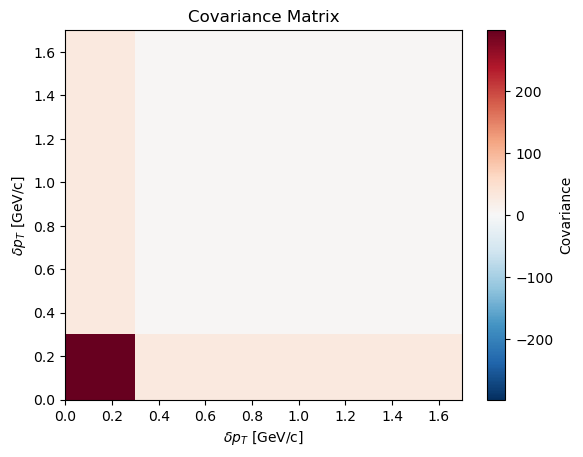

: 

In [7]:
def plot_cov_matrix(cov, binning_def, binning):

    if binning_def[1] is None:
            edges = binning.bin_edges
    else:
        edges = binning.bin_centers
            
    X, Y = np.meshgrid(edges,edges)
    max_val = np.max(np.abs(cov))
    plt.pcolormesh(X, Y, cov, cmap="RdBu_r", vmin=-max_val, vmax=max_val, shading='flat') #, norm=LogNorm())
    plt.colorbar(label = "Covariance")
    plt.xlabel(f'{binning.variable_tex}')
    plt.ylabel(f'{binning.variable_tex}')
    plt.title(f"Covariance Matrix")

plot_cov_matrix(genie_multisim_cov, binning_def, binning)
plt.show()

('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 1.7])



../../../microfit/run_plotter.py:125: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")


bkg var dict: 
 {'knobRPA': array([[8.37793002, 3.98581563],
       [8.4660572 , 4.03249835]]), 'knobCCMEC': array([[6.82812404, 4.02844762]]), 'knobAxFFCCQE': array([[8.42199361, 4.00915699]]), 'knobVecFFCCQE': array([[8.42199361, 4.00915699]]), 'knobDecayAngMEC': array([[8.42199361, 4.00915699]]), 'knobThetaDelta2Npi': array([[8.42199361, 4.00915699]])}

sig var dict: 
 {'knobRPA': array([[29.83354122,  8.27986516],
       [29.55095017,  8.38862061]]), 'knobCCMEC': array([[29.69473631,  8.33307234]]), 'knobAxFFCCQE': array([[29.70435606,  8.3281285 ]]), 'knobVecFFCCQE': array([[29.76356845,  8.308307  ]]), 'knobDecayAngMEC': array([[28.84588459,  8.34434935]]), 'knobThetaDelta2Npi': array([[29.6040932 ,  8.33549048]])}

total var dict: 
 {'knobRPA': array([[38.21147124, 12.2656808 ],
       [38.01700737, 12.42111896]]), 'knobCCMEC': array([[36.52286035, 12.36151997]]), 'knobAxFFCCQE': array([[38.12634967, 12.33728549]]), 'knobVecFFCCQE': array([[38.18556206, 12.317464  ]]), 'knobDeca

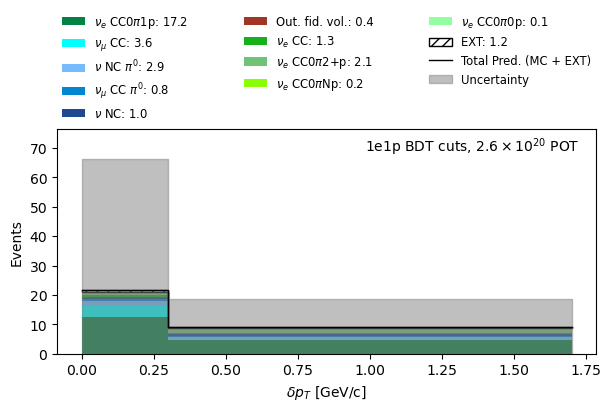

In [11]:
selection = "OnePBDT"
preselection = "OneP_new"

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    #binning = hist.Binning.from_config(*binning_def[:4])
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    print()
    label = binning_def[0].lstrip("Reco")

    signal_generator = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
        mc_hist_generator_cls = XsecCovarHistGenerator,
        true_var_name=None, 
        signal_query="category_1e1p == 12", 
        uncut_signal_df=rundata["nue"],
        normalization_uncertainty=[0.01,0.02]
        )
    
    plotter = rp.RunHistPlotter(signal_generator)
    axes = plotter.plot(
        category_column="category_1e1p",
        signal_category_num=12,
        include_multisim_errors=True,
        show_errorband=True,
    )

    plt.show()


In [14]:
mc_hists = signal_generator.get_mc_hists(
        category_column="category_1e1p",
    )
print(type(mc_hists))
for k, v in mc_hists.items():
    print(k)
    #print(type(k))
mc_sig = mc_hists[12].bin_counts
signal_category_num = 12
value = mc_hists.pop(signal_category_num)
mc_hists = {signal_category_num: value, **mc_hists}
print()
for k, v in mc_hists.items():
    print(k)
print(mc_hists)

<class 'dict'>
2
31
21
3
5
12
1
13
11
10

12
2
31
21
3
5
1
13
11
10
{12: Histogram(binning=Binning(variable='RecoDeltaPT', bin_edges=array([0. , 0.3, 1.7]), label='RecoDeltaPT', variable_tex='$\\delta p_T$ [GeV/c]', variable_tex_short=None, is_log=False, selection_query=None, selection_key='OnePBDT', preselection_key='OneP_new', selection_tex='1e1p BDT cuts', selection_tex_short='1e1p BDT cuts'), bin_counts=[12.60792462  4.63708572], label=$\nu_e$ CC0$\pi$1p, tex=$\nu_e$ CC0$\pi$1p), 2: Histogram(binning=Binning(variable='RecoDeltaPT', bin_edges=array([0. , 0.3, 1.7]), label='RecoDeltaPT', variable_tex='$\\delta p_T$ [GeV/c]', variable_tex_short=None, is_log=False, selection_query=None, selection_key='OnePBDT', preselection_key='OneP_new', selection_tex='1e1p BDT cuts', selection_tex_short='1e1p BDT cuts'), bin_counts=[3.62563306 0.        ], label=$\nu_{\mu}$ CC, tex=$\nu_{\mu}$ CC), 31: Histogram(binning=Binning(variable='RecoDeltaPT', bin_edges=array([0. , 0.3, 1.7]), label='RecoDel

In [14]:
print(bkg_dict[])

KeyError: 0

In [3]:
path = "/pnfs/uboone/persistent/users/cthorpe/PELEE_2023/run1/detvar/"
no_presel_path = path[:-1] # deletes the last '/'
no_presel_path = no_presel_path.rstrip('/detvar')
no_presel_path += "_detvar"
print(no_presel_path)

/pnfs/uboone/persistent/users/cthorpe/PELEE_2023/run1_detvar
